# 第 05 章 批次整合与方法比较

## 学习目标

比较整合方法对样本混合与群体结构的影响，明确下游使用的邻居图。

## 为什么做与怎样做

分别保存未整合、Harmony 和 BBKNN 的图与 UMAP。主线默认选择未整合图；改变选择会影响后续聚类和注释。

前置章节：04。运行前请完成项目环境准备。


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import sys
ROOT = Path(os.environ.get("SC_COURSE_ROOT", Path.cwd())).resolve()
while not (ROOT / "config/course.json").is_file() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config/course.json").is_file():
    raise RuntimeError("请从课程目录或其 notebooks/exercises 目录运行。")
os.environ["CELLTYPIST_FOLDER"] = str(ROOT / ".runtime/celltypist")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".runtime/matplotlib")
sys.path.insert(0, str(ROOT / "tools"))
from course_runtime import start_chapter, marker_sets, scaled_view
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
ctx = start_chapter("05")
adata = ctx.load_input()


第 05 章：批次整合与方法比较
结果目录：results/05_integration/20260915T073407_99a665


读取检查点：results/04_dimensionality/20260915T073130_f556ae/checkpoint.h5ad
17,041 个细胞 × 23,427 个基因


## 05.1 批次效应矫正

In [2]:
# 设置输出目录
sc.settings.figdir = ctx.figures

## 05.2 Harmony整合
Harmony [Korsunsky et al., 2019] 是一种用于整合来自多个实验的单细胞数据的算法。
该函数使用 Harmony 的 python 端口 Harmonypy 来集成存储在 AnnData 对象中的单细胞数据。
**由于 Harmony 通过调整主成分来工作，因此应在执行 PCA 之后但在计算邻居图之前运行该函数**

通常在查看1.6 邻近图构建与可视化_umap_samples的图时，你会看到批次之间有明显的分离。在这种情况下，我们看到的更加微妙，虽然来自同一标签的细胞通常彼此靠近，但批次之间存在偏移。如果我们使用此原始数据进行聚类分析，我们可能会得到一些仅包含单个批次的簇，这在注释阶段很难解释。我们也可能会忽略稀有细胞类型，这些细胞类型在任何单个样本中都不够常见，无法产生自己的簇。虽然 UMAP 通常可以显示批次效应，但在考虑这些 2D 表示时，重要的是不要过度解释它们。对于实际分析，你应该通过其他方式确认整合，例如检查标记基因的分布。在下面的“基准测试你自己的整合”部分，我们将讨论用于量化整合质量的指标。

现在我们已经确认存在需要校正的批次效应，我们可以继续讨论不同的整合方法。如果批次完全重叠，或者我们可以在不校正的情况下发现有意义的细胞簇，那么就不需要执行整合。

In [3]:
# 功能说明：定义批次键变量。
# 运行目的：指定用于批次校正的列名，方便后续函数调用。
# 详细代码解析：
# 1. `batch_key = "samples"`
#    - 将字符串 "samples" 赋值给变量 `batch_key`。
#    - "samples" 是 `adata.obs` 中记录样本来源的列名。

# 指定批次效应
batch_key = "samples"
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata.obsm["X_umap_uncorrected"] = adata.obsm["X_umap"].copy()


In [4]:

# key
# adata.obs 中区分实验/批次的列名称。要集成两个或多个协变量，您可以将多个列名称作为列表传递。有关更多详细信息，请参阅 Harmonypy 包的 vars_use 参数。
# basis
# （默认值：'X_pca'）
# adata.obsm 中存储 PCA 表的字段名称。默认为“X_pca”，这是 sc.pp.pca() 的默认值。
# adjusted_basis
# （默认值：'X_pca_harmony'）
# 运行此函数后，adata.obsm 中将存储调整后的 PCA 表的字段名称。默认为 X_pca_harmony。

# 其他一些参数
#   max_iter_harmony=20,  # 增加最大迭代次数
#   lambda_=0.5,         # 减小整合力度
#   theta=1.5,           # 调整多样性聚类惩罚参数
#   sigma=0.2,           # 调整软 k 均值聚类的宽度
#   nclust=30            # 调整聚类数量
sc.external.pp.harmony_integrate(adata, key="samples", basis='X_pca', adjusted_basis='X_pca_harmony',max_iter_harmony=20)

# 功能说明：构建 K 邻近图以表征细胞间相似性。
# 运行目的：为后续 UMAP 可视化与 Leiden 聚类建立图结构基础。
# 变量/函数/参数解析：
# - sc.pp.neighbors(adata,use_rep= "X_pca_harmony",key_added="X_pca_harmony")：
#   - 默认在 `obsm['X_pca']` 空间中构建邻近图并存入 `adata.obsp`。
#  use_rep= "X_pca_harmony"使用指定的表示形式。对于 .obsm，'X' 或任意键值均有效。若未指定（None）， 系统将自动选择表示形式：当 .n_vars < N_PCS（默认值：50）时采用 .X， 否则采用 'X_pca'。若当前不存在 'X_pca'，系统将使用默认参数或现有的 n_pcs 参数进行计算。
#  key_added="X_pca_harmony" #若未指定，邻居数据将存储在`.uns['neighbors']`中，距离和连接性分别存储在`.obsp['distances']`和`.obsp['connectivities']`中。若指定了存储键名，则邻居数据将添加至`.uns[key_added]`，距离存储在`.obsp[key_added+'_distances']`，连接性存储在`.obsp[key_added+'_connectivities']`
sc.pp.neighbors(adata,n_pcs= 50,use_rep= "X_pca_harmony",key_added="X_pca_harmony") 


2026-09-15 07:34:29,713 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-09-15 07:34:31,642 - harmonypy - INFO - sklearn.KMeans initialization complete.


2026-09-15 07:34:33,974 - harmonypy - INFO - Iteration 1 of 20


2026-09-15 07:34:40,506 - harmonypy - INFO - Iteration 2 of 20


2026-09-15 07:34:45,218 - harmonypy - INFO - Iteration 3 of 20


2026-09-15 07:34:50,380 - harmonypy - INFO - Iteration 4 of 20


2026-09-15 07:34:54,523 - harmonypy - INFO - Iteration 5 of 20


2026-09-15 07:34:56,010 - harmonypy - INFO - Converged after 5 iterations


/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/.envs/sc_rna/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


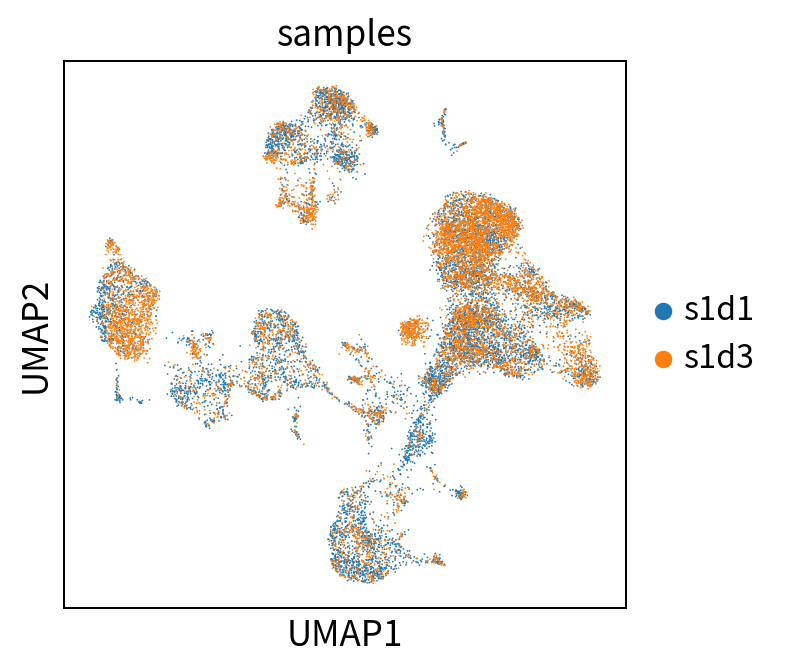

In [5]:
# 功能说明：基于 Harmony 整合结果计算并绘制 UMAP。
# 运行目的：可视化 Harmony 去除批次效应后的数据结构。
# 详细代码解析：
# 1. `sc.tl.umap(adata, neighbors_key="X_pca_harmony")`
#    - 使用基于 Harmony 结果构建的邻居图（key 为 "X_pca_harmony"）来计算 UMAP。
# 2. `sc.pl.umap(...)`
#    - 绘制 UMAP 图。
#    - `color=[batch_key]`: 按批次着色，检查不同批次的混合程度。
# 3. `adata`
#    - 查看对象状态。

# 计算并绘制umap
sc.tl.umap(adata,neighbors_key="X_pca_harmony")
sc.pl.umap(adata,color=[batch_key],size=2,save="_05_103.pdf")
adata
adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()


## 05.3 BBKNN整合


我们要看的下一个方法是 **BBKNN** 或“批次平衡 KNN” （参考文献：Polanski2019-zy）。这是一种与 **scVI** 非常不同的方法，它不是使用神经网络将细胞嵌入到批次校正空间中，而是修改用于聚类和嵌入的 _k_-最近邻 (KNN) 图的构建方式，正常的 KNN 过程将细胞连接到整个数据集中最相似的细胞。**BBKNN** 所做的改变是强制细胞连接到来自其他批次的细胞。虽然这是一个简单的修改，但它可能非常有效，特别是当存在非常强的批次效应时。然而，由于输出是一个整合图，它的下游用途可能有限，因为很少有包会接受这个作为输入。

**BBKNN 的一个重要参数是每个批次的邻居数量。对此的一个建议启发式方法是，如果有超过 100,000 个细胞，则使用 25，如果少于 100,000 个，则使用默认值 3。**

In [6]:
# 功能说明：设置BBKNN算法的参数。
# 运行目的：确定每个批次内要查找的邻居数量。这是一个启发式参数，取决于数据规模。
# 详细代码解析：
# 1. `neighbors_within_batch = 25 if adata_hvg.n_obs > 100000 else 3`
#    - 这是一个条件赋值语句。
#    - 如果细胞总数（`n_obs`）大于100,000，则设置`neighbors_within_batch`为25。
#    - 否则（我们的情况），设置为3。
#    - 这个参数控制BBKNN在构建图时，对于每个细胞，在每个其他批次中寻找多少个最近邻。

neighbors_within_batch = 25 if adata_hvg.n_obs > 100000 else 3
neighbors_within_batch

3

在使用 **BBKNN** 之前，我们首先执行 PCA，就像我们在构建正常的 KNN 图之前所做的那样。与在这里对原始计数进行建模的 **scVI** 不同，我们从对数归一化的表达矩阵开始。

我们现在可以运行 **BBKNN**，替换标准工作流程中对 **scanpy** `neighbors()` 函数的调用。一个重要的区别是确保设置了 `batch_key` 参数，该参数指定 `adata.obs` 中包含批次标签的列。

In [7]:
# 功能说明：导入 bbknn 库。
# 运行目的：加载用于批次平衡 KNN（Batch Balanced KNN）整合的工具。
# 详细代码解析：
# 1. `import bbknn`
#    - 导入 bbknn 模块。

import bbknn

In [8]:
# 功能说明：运行BBKNN算法。
# 运行目的：通过修改邻居图来校正批次效应。BBKNN强制每个细胞连接到来自不同批次的邻居，从而将不同批次“拉”到一起。
# 详细代码解析：
# 1. `bbknn.bbknn(...)`
#    - 调用BBKNN函数。
#    - `adata`: AnnData对象。
#    - `batch_key=batch_key`: 指定批次列。
#    - `neighbors_within_batch=neighbors_within_batch`: 指定每个批次的邻居数（之前计算为3）。
#    - 该函数直接修改`adata`，更新其邻居图（`obsp["distances"]`和`obsp["connectivities"]`）。
# 2. `adata`
#    - 打印对象摘要。
adata.X = adata.layers["log1p"].copy()

sc.external.pp.bbknn(adata, batch_key="samples", use_rep='X_pca',  neighbors_within_batch=neighbors_within_batch,key_added="X_pca_bbknn" )

adata

AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'samples', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'samples_colors', 'scrublet', 'tsne', 'umap', 'X_pca_harmony', 'X_pca_bbknn'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_umap_uncorrected', 'X_pca_harmony', '



我们可以像使用普通 KNN 图一样使用这个新的整合图来构建 UMAP 嵌入。

In [9]:
# 功能说明：基于BBKNN校正后的图绘制UMAP。
# 运行目的：可视化BBKNN的整合效果。
# 详细代码解析：
# 1. `sc.tl.umap(adata_bbknn)`
#    - 使用BBKNN生成的邻居图计算UMAP。
# 2. `sc.pl.umap(...)`
#    - 绘制UMAP图。

sc.tl.umap(adata,neighbors_key="X_pca_bbknn")


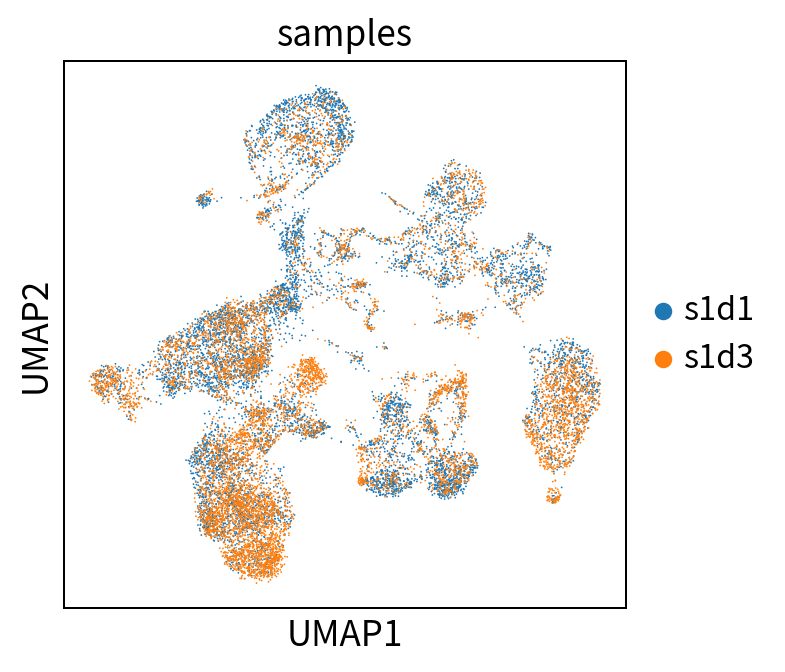

In [10]:
# 功能说明：绘制 BBKNN 整合后的 UMAP 图。
# 运行目的：可视化 BBKNN 整合效果，检查批次混合情况。
# 详细代码解析：
# 1. `sc.pl.umap(...)`
#    - 绘制 UMAP。
#    - `color=[batch_key]`: 按批次着色。
#    - `size=2`: 设置点的大小。

sc.pl.umap(adata, color=[batch_key],size=2,save="_05_114.pdf")
adata.obsm["X_umap_bbknn"] = adata.obsm["X_umap"].copy()


## 05.4 选择下游分析表示

主线默认使用未整合邻居图。Harmony 和 BBKNN 的邻居图、UMAP 坐标分别保存，便于比较。参数 integration 可选择 uncorrected、harmony 或 bbknn；选择改变后需重新运行后续章节，并重新核对细胞类型注释。

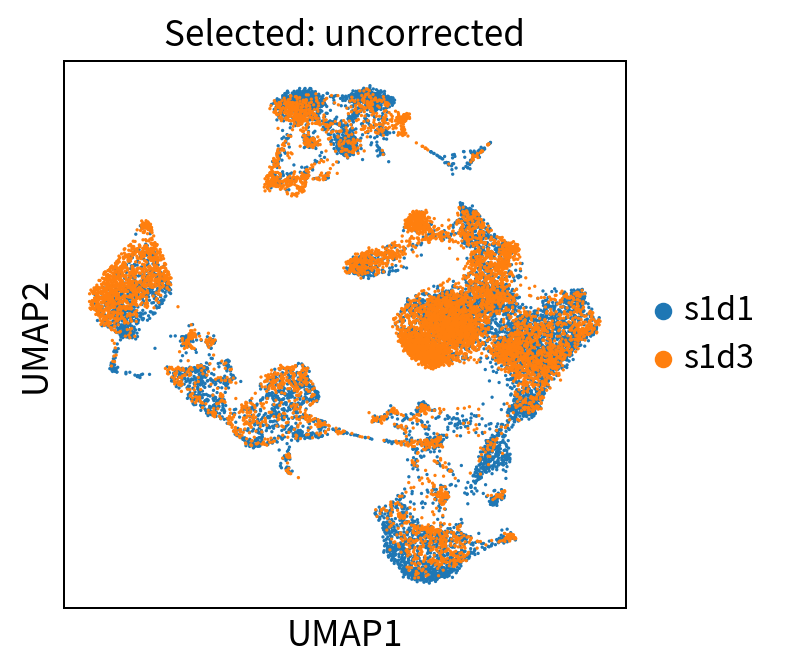

In [11]:
graph_keys = {"uncorrected": "neighbors", "harmony": "X_pca_harmony", "bbknn": "X_pca_bbknn"}
selected_method = ctx.config["parameters"]["integration"]
neighbors_key = graph_keys[selected_method]
adata.uns["course_neighbors_key"] = neighbors_key
sc.tl.umap(adata, neighbors_key=neighbors_key, random_state=0)
sc.pl.umap(adata, color="samples", title="Selected: " + selected_method, save="_05_145.pdf")

## 保存本章结果

保存表格、参数摘要和可供后续章节读取的数据。

In [12]:
for method in ["uncorrected", "harmony", "bbknn"]:
    ctx.table("umap_" + method, pd.DataFrame(adata.obsm["X_umap_" + method], index=adata.obs_names, columns=["UMAP1", "UMAP2"]).join(adata.obs[["samples"]]))
ctx.finish(adata, {"selected_integration": ctx.config["parameters"]["integration"], "neighbors_key": adata.uns["course_neighbors_key"], "computed_methods": ["uncorrected", "harmony", "bbknn"]})

本章计算完成。请阅读本次图表和表格，再更新本章解读。


## 结果阅读与思考

请打开本次结果目录中的 summary.json、tables 和 figures。将目的、方法、结果和解释写入本章报告源稿，再更新 Word。

思考题：样本混合得越充分，是否一定说明整合越好？

运行与报告操作见课程根目录的 99_运行与AI协作指南.md。